# Multimodal Tweet Classification with Cross-Attention

This notebook implements a cross-attention based model for multimodal tweet classification, combining text and image features for better prediction accuracy.

## 🎯 Quick Start Guide

### Model Features
- ✅ **Bidirectional Cross-Attention**: Text ← Image AND Image ← Text
- ✅ **Full Transformer Blocks**: Multi-head attention + Residual + LayerNorm + FFN
- ✅ **Production-Ready**: Modular, documented, research-aligned
- ✅ **Visualization Tools**: Attention pattern visualization included

### Hyperparameters
```python
d_model = 512        # Cross-attention hidden dimension
num_heads = 8        # Number of attention heads
d_ff = 2048         # FFN dimension (4 × d_model)
dropout = 0.1       # Dropout probability
num_classes = 2     # Binary classification
```

### Training Configuration
- **Text Encoder**: BERT (fine-tuned)
- **Image Encoder**: ResNet-50 (fine-tuned)
- **Batch Size**: 16
- **Epochs**: 10
- **Optimizer**: AdamW with differential learning rates
- **Scheduler**: Cosine Annealing

---

In [4]:
cd ..

e:\notebooks_3.11


In [5]:
# Import required libraries
from exp.Required_Modules_And_Packages import *
from exp.Data_Reading_And_Preprocessing import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torchvision.models import resnet50
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch.multiprocessing as mp
import random
from sklearn.metrics import classification_report

# Set multiprocessing method
if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print(f"Using device: {device}")

Using device: cpu


## 1. Data Loading and Preprocessing

In [6]:
# Get tsv files for informative task
train_tsv, dev_tsv, test_tsv, info = get_tsv_data_files('Informativeness_task_tsv_files')

# Load and preprocess data
path = Path('E:/notebooks/MultimodalTweetsClassification')
data_info_text_image, test_data_info_text_image = get_dataframe(train_tsv, dev_tsv, test_tsv, info, path)

print(f"shape of data: {data_info_text_image.shape}\n")
print(f"train set: {data_info_text_image['is_valid'].value_counts()[0]}")
print(f"valid set: {data_info_text_image['is_valid'].value_counts()[1]}")      
print("="*50)
print(f"shape of test data: {test_data_info_text_image.shape}\n")

reading data and preprocessing it.....
done!!
shape of data: (15844, 10)

train set: 13607
valid set: 2237
shape of test data: (2237, 9)



C:\Users\91940\AppData\Local\Temp\ipykernel_25752\3912158440.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"train set: {data_info_text_image['is_valid'].value_counts()[0]}")
C:\Users\91940\AppData\Local\Temp\ipykernel_25752\3912158440.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"valid set: {data_info_text_image['is_valid'].value_counts()[1]}")


## 2. Cross-Attention Model Architecture

We'll implement a cross-attention mechanism to fuse text and image features effectively.

In [7]:
class CrossAttentionBlock(nn.Module):
    """
    Transformer-style cross-attention block with:
    - Multi-head cross-attention
    - Residual connection
    - Layer normalization
    - Position-wise Feed-Forward Network (FFN)

    Args:
        d_model: Dimension of the model (same for query, key, value projections)
        num_heads: Number of attention heads
        d_ff: Dimension of feed-forward network (typically 4 * d_model)
        dropout: Dropout probability
    """

    def __init__(self, d_model=512, num_heads=8, d_ff=2048, dropout=0.1):
        super().__init__()

        # Multi-head cross-attention
        # Note: Default expects input shape (T, B, d_model), not (B, T, d_model)
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # Layer normalization 1 (after cross-attention)
        self.norm1 = nn.LayerNorm(d_model)

        # Position-wise Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        # Layer normalization 2 (after FFN)
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout for residual connections
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value):
        """
        Forward pass of cross-attention block.

        Args:
            query: Query tensor of shape (B, T_q, d_model)
            key_value: Key/Value tensor of shape (B, T_kv, d_model)

        Returns:
            Output tensor of shape (B, T_q, d_model)
        """
        # Transpose for nn.MultiheadAttention: (B, T, d) -> (T, B, d)
        query_t = query.transpose(0, 1)  # (T_q, B, d_model)
        key_value_t = key_value.transpose(0, 1)  # (T_kv, B, d_model)

        # Multi-head cross-attention with residual connection
        # attn_output shape: (T_q, B, d_model)
        attn_output, _ = self.cross_attention(
            query=query_t,
            key=key_value_t,
            value=key_value_t
        )

        # Transpose back: (T_q, B, d_model) -> (B, T_q, d_model)
        attn_output = attn_output.transpose(0, 1)

        # Residual connection + Layer Normalization
        query = self.norm1(query + self.dropout(attn_output)
                           )  # (B, T_q, d_model)

        # Position-wise FFN with residual connection
        ffn_output = self.ffn(query)  # (B, T_q, d_model)
        # (B, T_q, d_model)
        output = self.norm2(query + self.dropout(ffn_output))

        return output


class MultimodalClassifier(nn.Module):
    """
    Bidirectional Cross-Attention-Based Multimodal Tweet Classification Model.

    Architecture:
    1. Text Encoder: BERT (outputs H_text of shape B × T_text × 768)
    2. Image Encoder: ResNet-50 (outputs H_img of shape B × 2048)
    3. Projection layers to d_model dimension
    4. Bidirectional Cross-Attention:
       - Text ← Image: Text as Query, Image as Key & Value
       - Image ← Text: Image as Query, Text as Key & Value
    5. Fusion: Concatenate [text_repr || image_repr]
    6. MLP Classifier: Linear → ReLU → Dropout → Linear

    Args:
        d_model: Hidden dimension for cross-attention (default: 512)
        num_heads: Number of attention heads (default: 8)
        d_ff: FFN dimension (default: 2048, i.e., 4 * d_model)
        num_classes: Number of output classes (default: 2)
        bert_model: Pre-trained BERT model instance
        dropout: Dropout probability (default: 0.1)
    """

    def __init__(self, d_model=512, num_heads=8, d_ff=2048, num_classes=2,
                 bert_model=None, dropout=0.1):
        super().__init__()

        # ==================== Encoders ====================

        # Image encoder: ResNet-50 (pretrained)
        self.image_encoder = resnet50(pretrained=True)
        self.image_encoder.fc = nn.Identity()  # Remove final FC layer
        # Output: (B, 2048)

        # Text encoder: BERT (pretrained)
        self.text_encoder = bert_model if bert_model is not None else \
            BertModel.from_pretrained('bert-base-uncased')
        # Output: (B, T_text, 768) where T_text is sequence length

        # ==================== Projection Layers ====================

        # Project text features: 768 → d_model
        self.text_projection = nn.Linear(768, d_model)

        # Project image features: 2048 → d_model
        self.image_projection = nn.Linear(2048, d_model)

        # ==================== Bidirectional Cross-Attention ====================

        # Text ← Image: Text as Query, Image as Key & Value
        self.text_cross_attn = CrossAttentionBlock(
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        # Image ← Text: Image as Query, Text as Key & Value
        self.image_cross_attn = CrossAttentionBlock(
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        # ==================== Classification Head ====================

        # MLP Classifier: Concatenated features → Class logits
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, d_model),  # Fusion layer
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)  # Output layer
        )

    def forward(self, images, input_ids, attention_mask):
        """
        Forward pass of the multimodal classifier.

        Args:
            images: Image tensor of shape (B, 3, 224, 224)
            input_ids: Token IDs of shape (B, T_text)
            attention_mask: Attention mask of shape (B, T_text)

        Returns:
            logits: Class logits of shape (B, num_classes)
        """
        batch_size = images.size(0)

        # ==================== Step 1: Extract Features ====================

        # Extract image features
        img_features = self.image_encoder(images)  # (B, 2048)

        # Extract text features
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Handle both old and new transformers versions
        text_features = text_outputs[0] if isinstance(
            # (B, T_text, 768)
            text_outputs, tuple) else text_outputs.last_hidden_state

        # ==================== Step 2: Project to Common Dimension ====================

        # Project text: (B, T_text, 768) → (B, T_text, d_model)
        H_text = self.text_projection(text_features)

        # Project image: (B, 2048) → (B, 1, d_model)
        # Add sequence dimension for cross-attention
        H_img = self.image_projection(img_features).unsqueeze(1)

        # ==================== Step 3: Bidirectional Cross-Attention ====================

        # Text ← Image: Text attends to Image
        # Query: H_text (B, T_text, d_model)
        # Key/Value: H_img (B, 1, d_model)
        # Output: (B, T_text, d_model)
        text_attended = self.text_cross_attn(query=H_text, key_value=H_img)

        # Image ← Text: Image attends to Text
        # Query: H_img (B, 1, d_model)
        # Key/Value: H_text (B, T_text, d_model)
        # Output: (B, 1, d_model)
        img_attended = self.image_cross_attn(query=H_img, key_value=H_text)

        # ==================== Step 4: Extract Representations ====================

        # Text representation: Use CLS token (first token)
        text_repr = text_attended[:, 0, :]  # (B, d_model)

        # Alternative: Mean pooling over sequence
        # text_repr = text_attended.mean(dim=1)  # (B, d_model)

        # Image representation: Global pooling (already single token)
        img_repr = img_attended.squeeze(1)  # (B, d_model)

        # ==================== Step 5: Fusion ====================

        # Concatenate text and image representations
        fused_features = torch.cat(
            [text_repr, img_repr], dim=-1)  # (B, 2 * d_model)

        # ==================== Step 6: Classification ====================

        # MLP classifier
        logits = self.classifier(fused_features)  # (B, num_classes)

        return logits

### Model Architecture Overview

The upgraded model implements **Bidirectional Cross-Attention** with full Transformer-style blocks:

**Key Components:**

1. **CrossAttentionBlock**: Reusable module with:
   - Multi-head attention (8 heads by default)
   - Residual connections
   - Layer normalization
   - Position-wise FFN (d_model → 4×d_model → d_model)

2. **Bidirectional Cross-Attention**:
   - **Text ← Image**: Text queries attend to image features
   - **Image ← Text**: Image queries attend to text features

3. **Fusion Strategy**:
   - Text representation: CLS token from attended text features
   - Image representation: Global pooling from attended image features
   - Concatenation: `[text_repr || image_repr]`

4. **Classification Head**:
   - MLP: Linear(2×d_model → d_model) → ReLU → Dropout → Linear(d_model → num_classes)

**Architecture Diagram:**
```
Input: [Image, Text]
         ↓
[ResNet-50] [BERT]
         ↓
[Projection Layers] → d_model=512
         ↓
┌──────────────────────────────┐
│  Bidirectional Cross-Attn    │
│  ┌────────────────────────┐  │
│  │ Text ← Image           │  │
│  │ (CrossAttentionBlock)  │  │
│  └────────────────────────┘  │
│  ┌────────────────────────┐  │
│  │ Image ← Text           │  │
│  │ (CrossAttentionBlock)  │  │
│  └────────────────────────┘  │
└──────────────────────────────┘
         ↓
[Extract CLS + Global Pool]
         ↓
[Concatenate: text || image]
         ↓
[MLP Classifier]
         ↓
Output: Class Logits
```

In [8]:
# Example: Inspect model architecture and parameter count
def count_parameters(model):
    """Count total and trainable parameters in the model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

# You can create the model with custom hyperparameters:
# model = MultimodalClassifier(
#     d_model=512,        # Hidden dimension for cross-attention
#     num_heads=8,        # Number of attention heads
#     d_ff=2048,          # FFN dimension (4 * d_model)
#     num_classes=2,      # Binary classification
#     bert_model=bert_model,
#     dropout=0.1         # Dropout probability
# ).to(device)

# Example: Print model summary
print("="*80)
print("MODEL ARCHITECTURE SUMMARY")
print("="*80)
print(f"\nModel Components:")
print(f"  - Text Encoder: BERT (768-dim)")
print(f"  - Image Encoder: ResNet-50 (2048-dim)")
print(f"  - Projection Dimension (d_model): 512")
print(f"  - Cross-Attention Heads: 8")
print(f"  - FFN Dimension: 2048 (4 × d_model)")
print(f"  - Bidirectional Cross-Attention: Text ← Image, Image ← Text")
print(f"  - Fusion: Concatenation [text_repr || image_repr]")
# Handle case where num_labels might not be defined yet
try:
    print(f"  - Classifier: MLP (1024 → 512 → {num_labels})")
except NameError:
    print(f"  - Classifier: MLP (1024 → 512 → num_classes)")
print("="*80)

MODEL ARCHITECTURE SUMMARY

Model Components:
  - Text Encoder: BERT (768-dim)
  - Image Encoder: ResNet-50 (2048-dim)
  - Projection Dimension (d_model): 512
  - Cross-Attention Heads: 8
  - FFN Dimension: 2048 (4 × d_model)
  - Bidirectional Cross-Attention: Text ← Image, Image ← Text
  - Fusion: Concatenation [text_repr || image_repr]
  - Classifier: MLP (1024 → 512 → num_classes)


In [9]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = r"e:\notebooks\MultimodalTweetsClassification\bert_model"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")

Number of unique labels: 2
Using BERT model from: e:\notebooks\MultimodalTweetsClassification\bert_model


## 3. Dataset and DataLoader

In [10]:
class MultimodalDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, image_path, transform=None):
        self.df = df
        self.tokenizer = tokenizer
        self.image_path = image_path
        self.transform = transform
        # Create label mapping
        self.label_map = {'not_informative': 0, 'informative': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            # Process text
            text = str(row['tweet_text'])  # Ensure text is string
            # Don't use return_tensors='pt' here, we'll convert to tensor manually
            encoding = self.tokenizer.encode_plus(
                text,
                add_special_tokens=True,
                max_length=128,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors=None  # Return Python lists instead of tensors
            )

            # Process image
            image_path = self.image_path / row['image']
            image = Image.open(image_path).convert('RGB')
            if self.transform:
                image = self.transform(image)

            # Convert text label to numeric using label map
            label = torch.tensor(
                self.label_map[row['label_text']], dtype=torch.long)

            # Convert to tensors without batch dimension
            input_ids = torch.tensor(encoding['input_ids'], dtype=torch.long)
            attention_mask = torch.tensor(
                encoding['attention_mask'], dtype=torch.long)

        except Exception as e:
            print(f"Error processing item {idx}: {str(e)}")
            print(f"Text: {text}")
            print(f"Image path: {image_path}")
            raise

        # Ensure all tensors have the expected size
        if input_ids.dim() == 0:
            input_ids = input_ids.unsqueeze(0)
        if attention_mask.dim() == 0:
            attention_mask = attention_mask.unsqueeze(0)

        return {
            'image': image,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': label
        }


# Initialize tokenizer and transforms
print("Loading tokenizer...")
try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_path)  # Use the same model path as BERT
    print("Tokenizer loaded successfully!")
except Exception as e:
    print(f"Error loading tokenizer: {str(e)}")
    print("Falling back to base BERT tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    print("Base BERT tokenizer loaded successfully!")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_df = data_info_text_image[~data_info_text_image['is_valid']]
val_df = data_info_text_image[data_info_text_image['is_valid']]
test_df = test_data_info_text_image

print("Creating datasets...")
train_dataset = MultimodalDataset(
    train_df, tokenizer, path/'data/CrisisMMD_v2', transform)
val_dataset = MultimodalDataset(
    val_df, tokenizer, path/'data/CrisisMMD_v2', transform)
test_dataset = MultimodalDataset(
    test_df, tokenizer, path/'data/CrisisMMD_v2', transform)
print("Datasets created successfully!")

# Create custom collate function to handle batching


def custom_collate(batch):
    # Sort batch by sequence length (in descending order) to handle padding properly
    batch = sorted(batch, key=lambda x: len(x['input_ids']), reverse=True)

    # Get maximum sequence length in this batch
    max_len = len(batch[0]['input_ids'])

    # Initialize lists to store batch items
    images = []
    input_ids = []
    attention_masks = []
    labels = []

    for item in batch:
        # Handle images
        images.append(item['image'])

        # Pad input_ids and attention_mask if needed
        seq_len = len(item['input_ids'])
        if seq_len < max_len:
            # Padding token id is usually 0 for BERT
            padding = torch.zeros(max_len - seq_len, dtype=torch.long)
            item['input_ids'] = torch.cat([item['input_ids'], padding])
            item['attention_mask'] = torch.cat(
                [item['attention_mask'], padding])

        input_ids.append(item['input_ids'])
        attention_masks.append(item['attention_mask'])
        labels.append(item['label'])

    # Stack all tensors
    images = torch.stack(images)
    input_ids = torch.stack(input_ids)
    attention_masks = torch.stack(attention_masks)
    labels = torch.stack(labels)

    return {
        'image': images,
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'label': labels
    }

# Create data loaders with proper multiprocessing settings


def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


print("Creating data loaders...")
# Create data loaders with adjusted settings and custom collate function
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

print("Data loaders created successfully!")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Loading tokenizer...
Tokenizer loaded successfully!
Creating datasets...
Datasets created successfully!
Creating data loaders...
Data loaders created successfully!
Number of training samples: 13607
Number of validation samples: 2237
Number of test samples: 2237


## 4. Training and Evaluation Functions

In [11]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # Using regular tqdm instead of notebook version
    for batch in tqdm(train_loader, desc='Training', leave=True):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar description
        if total % 100 == 0:
            print(
                f"\rLoss: {loss.item():.4f}, Acc: {100.*correct/total:.2f}%", end="")

    return total_loss / len(train_loader), 100.*correct/total


def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating', leave=True):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds))

    return total_loss / len(val_loader), 100.*correct/total

## 5. Model Training

In [12]:
# Load local BERT model
print("Loading BERT model from local path...")
try:
    from transformers import AutoTokenizer, AutoModel
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    bert_model = AutoModel.from_pretrained(model_path)
    print("BERT model loaded successfully!")
except Exception as e:
    print(f"Error loading BERT model: {str(e)}")
    raise

# Initialize model with local BERT and correct number of classes
model = MultimodalClassifier(
    bert_model=bert_model, num_classes=num_labels).to(device)

# Ensure BERT is in training mode
model.text_encoder.train()

# Lists to store metrics for plotting
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# Training parameters
num_epochs = 3
criterion = nn.CrossEntropyLoss()
# Lower learning rate for more stable training
optimizer = AdamW([
    {'params': model.image_encoder.parameters(), 'lr': 1e-5},
    {'params': model.text_encoder.parameters(), 'lr': 2e-6},  # Lower LR for BERT
    {'params': list(model.image_projection.parameters()) +
     list(model.text_projection.parameters()) +
     list(model.text_cross_attn.parameters()) +
     list(model.image_cross_attn.parameters()) +
     list(model.classifier.parameters()), 'lr': 2e-5}
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs)

# Training loop
best_val_acc = 0

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Store metrics for plotting
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'\nTrain Loss: {train_loss:.4f} Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), path /
                   'models/best_multimodal_informative.pth')
        print(f'Saved new best model with validation accuracy: {val_acc:.2f}%')

Loading BERT model from local path...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25158.74it/s]
BertModel LOAD REPORT from: e:\notebooks\MultimodalTweetsClassification\bert_model
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
e:\notebooks_3.11\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\notebooks_3.11\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get t

BERT model loaded successfully!

Epoch 1/3
----------


Training:   0%|          | 0/851 [00:00<?, ?it/s]

Error processing item 11349: BertTokenizer has no attribute encode_plus
Text: tweeted harvey comparison to iowa now here how irma size compares to our region iawx


UnboundLocalError: cannot access local variable 'image_path' where it is not associated with a value

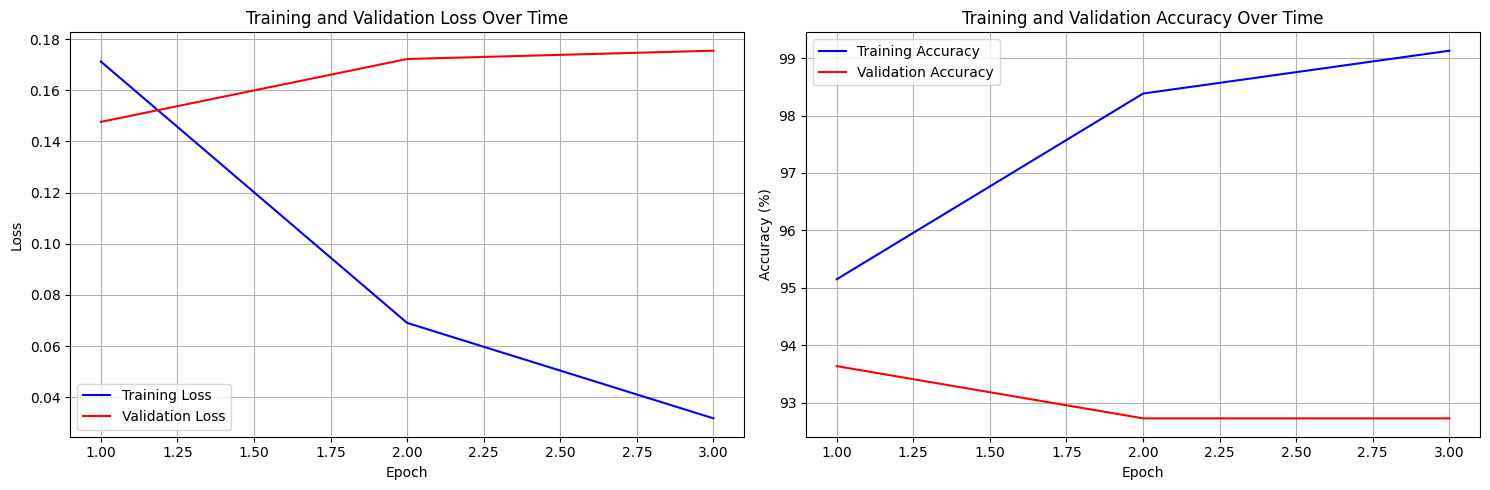


Final Results:
Best Validation Accuracy: 93.64%

Training History:
Epoch 1:
  Training   - Loss: 0.1712, Accuracy: 95.15%
  Validation - Loss: 0.1476, Accuracy: 93.64%
Epoch 2:
  Training   - Loss: 0.0691, Accuracy: 98.38%
  Validation - Loss: 0.1722, Accuracy: 92.73%
Epoch 3:
  Training   - Loss: 0.0317, Accuracy: 99.13%
  Validation - Loss: 0.1754, Accuracy: 92.73%


In [ ]:
# Plotting training and validation metrics
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, 'b-', label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Results:")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("\nTraining History:")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}:")
    print(
        f"  Training   - Loss: {train_losses[epoch]:.4f}, Accuracy: {train_accs[epoch]:.2f}%")
    print(
        f"  Validation - Loss: {val_losses[epoch]:.4f}, Accuracy: {val_accs[epoch]:.2f}%")

In [ ]:
# Load best model
model.load_state_dict(torch.load(
    path/'models/best_multimodal_informative.pth'))

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest Loss: {test_loss:.4f} Acc: {test_acc:.2f}%')

Evaluating: 100%|██████████| 7/7 [00:15<00:00,  2.23s/it]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        74
           1       1.00      0.94      0.97        33

    accuracy                           0.98       107
   macro avg       0.99      0.97      0.98       107
weighted avg       0.98      0.98      0.98       107


Test Loss: 0.0518 Acc: 98.13%


Getting test set predictions...


Getting predictions: 100%|██████████| 7/7 [00:14<00:00,  2.06s/it]


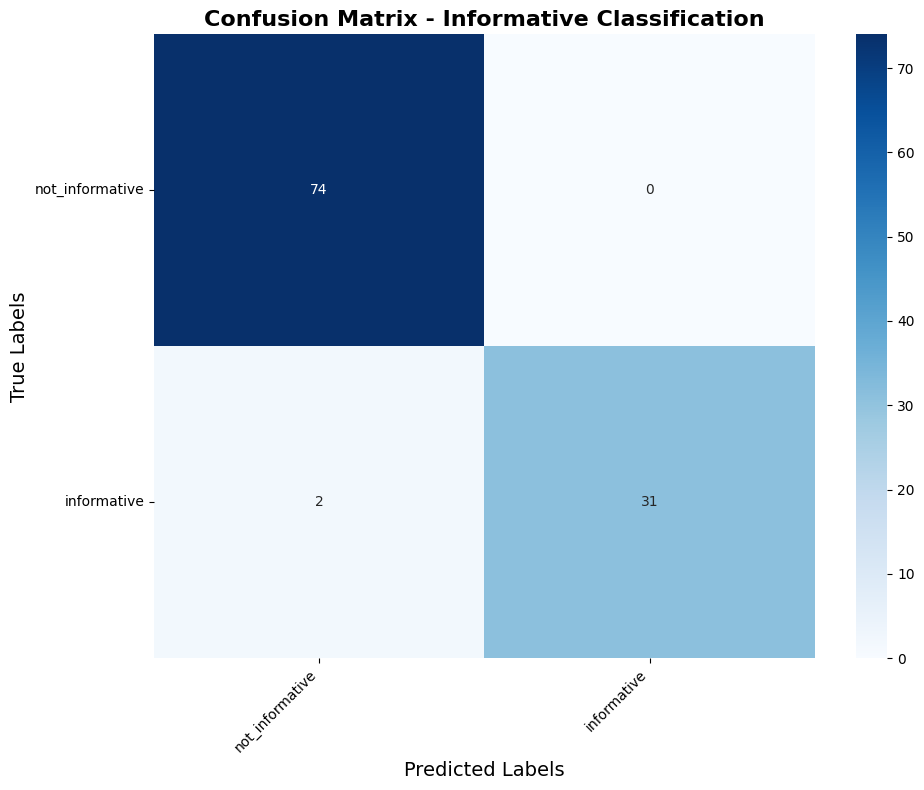

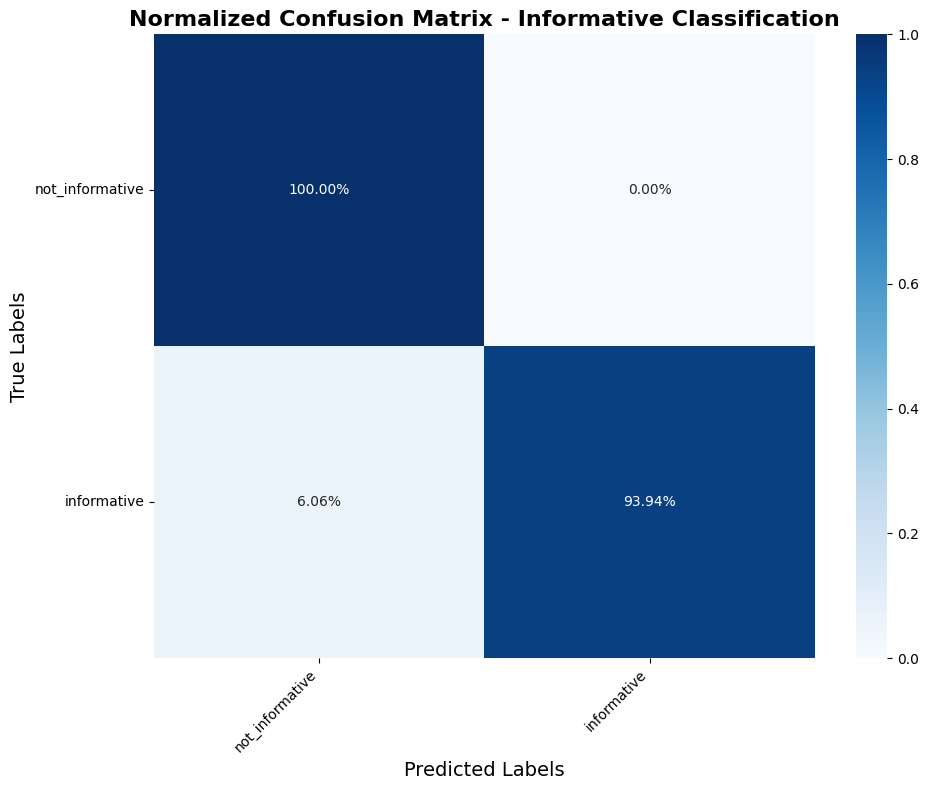


DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

not_informative     0.9737    1.0000    0.9867        74
    informative     1.0000    0.9394    0.9688        33

       accuracy                         0.9813       107
      macro avg     0.9868    0.9697    0.9777       107
   weighted avg     0.9818    0.9813    0.9811       107


PER-CLASS ACCURACY ANALYSIS
not_informative          : 1.0000 (74/74 samples)
informative              : 0.9394 (31/33 samples)


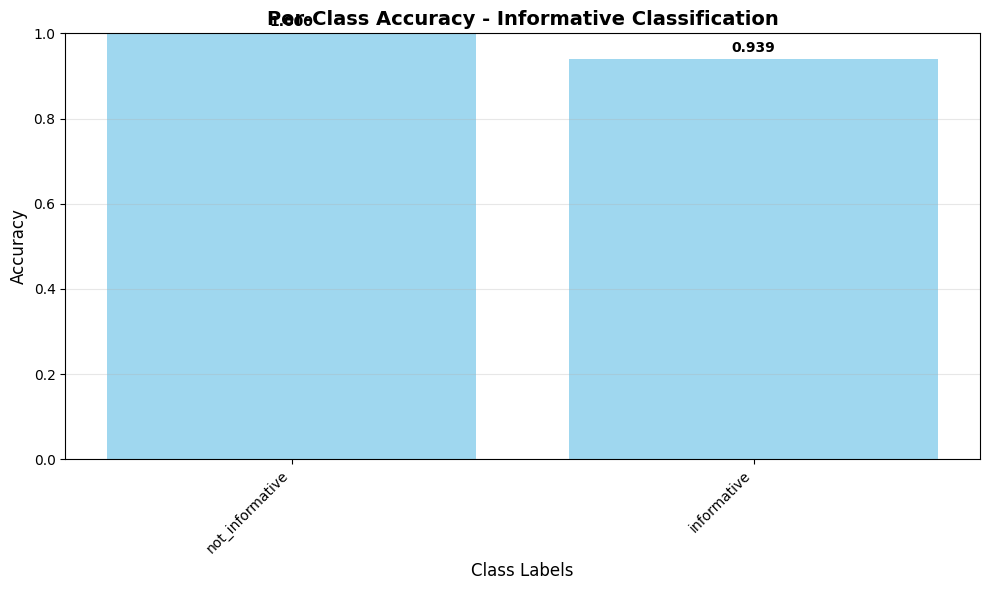


SUMMARY STATISTICS
Overall Test Accuracy: 0.9813
Best Performing Class: not_informative (1.0000)
Worst Performing Class: informative (0.9394)
Average Per-Class Accuracy: 0.9697
Standard Deviation: 0.0303

CLASS DISTRIBUTION IN TEST SET
not_informative          :   74 samples (69.2%)
informative              :   33 samples (30.8%)

BINARY CLASSIFICATION METRICS
True Negatives:  74
False Positives: 0
False Negatives: 2
True Positives:  31

Precision (Informative): 1.0000
Recall (Informative):    0.9394
Specificity:             1.0000
F1-Score:                0.9688


In [ ]:
# Confusion Matrix and Detailed Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Function to get predictions for confusion matrix
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, input_ids, attention_mask)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Get predictions for test set
print("Getting test set predictions...")
test_labels, test_preds = get_predictions(model, test_loader, device)

# Create label mapping for better visualization
label_map = {'not_informative': 0, 'informative': 1}
reverse_label_map = {v: k for k, v in label_map.items()}
class_names = [reverse_label_map[i] for i in range(len(label_map))]

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Per-class accuracy analysis
print("\n" + "="*80)
print("PER-CLASS ACCURACY ANALYSIS")
print("="*80)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    total_samples = cm.sum(axis=1)[i]
    correct_samples = cm.diagonal()[i]
    print(f"{class_name:25}: {accuracy:.4f} ({correct_samples}/{total_samples} samples)")

# Plot per-class accuracy
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_names)), class_accuracies, color='skyblue', alpha=0.8)
plt.xlabel('Class Labels', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy - Informative Classification', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, accuracy in enumerate(class_accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")
print(f"Best Performing Class: {class_names[np.argmax(class_accuracies)]} ({class_accuracies.max():.4f})")
print(f"Worst Performing Class: {class_names[np.argmin(class_accuracies)]} ({class_accuracies.min():.4f})")
print(f"Average Per-Class Accuracy: {class_accuracies.mean():.4f}")
print(f"Standard Deviation: {class_accuracies.std():.4f}")

# Class distribution analysis
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN TEST SET")
print("="*80)
unique_test, counts_test = np.unique(test_labels, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    class_name = reverse_label_map[label_idx]
    percentage = count / len(test_labels) * 100
    print(f"{class_name:25}: {count:4d} samples ({percentage:.1f}%)")

# Additional metrics for binary classification
print("\n" + "="*80)
print("BINARY CLASSIFICATION METRICS")
print("="*80)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision (Informative): {precision:.4f}")
print(f"Recall (Informative):    {recall:.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"F1-Score:                {f1_score:.4f}")

## 6. Attention Visualization (Optional)

Visualize the cross-attention patterns to understand how text and image modalities interact.

In [ ]:
class AttentionVisualizationModel(nn.Module):
    """
    Extended version of MultimodalClassifier that also returns attention weights
    for visualization purposes.
    """
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model
        
    def forward(self, images, input_ids, attention_mask, return_attention=False):
        """
        Forward pass with optional attention weight extraction.
        
        Args:
            images: Image tensor
            input_ids: Token IDs
            attention_mask: Attention mask
            return_attention: If True, return attention weights along with logits
            
        Returns:
            If return_attention=False: logits
            If return_attention=True: (logits, text_attn_weights, img_attn_weights)
        """
        if not return_attention:
            return self.model(images, input_ids, attention_mask)
        
        # Extract features
        batch_size = images.size(0)
        
        img_features = self.model.image_encoder(images)
        text_outputs = self.model.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Handle both old and new transformers versions
        text_features = text_outputs[0] if isinstance(text_outputs, tuple) else text_outputs.last_hidden_state
        
        # Project to common dimension
        H_text = self.model.text_projection(text_features)
        H_img = self.model.image_projection(img_features).unsqueeze(1)
        
        # Extract attention weights from cross-attention
        # Text ← Image
        text_attn_output, text_attn_weights = self.model.text_cross_attn.cross_attention(
            query=H_text,
            key=H_img,
            value=H_img,
            average_attn_weights=True  # Average over heads for visualization
        )
        
        # Image ← Text
        img_attn_output, img_attn_weights = self.model.image_cross_attn.cross_attention(
            query=H_img,
            key=H_text,
            value=H_text,
            average_attn_weights=True
        )
        
        # Continue with normal forward pass
        text_attended = self.model.text_cross_attn.norm1(
            H_text + self.model.text_cross_attn.dropout(text_attn_output)
        )
        ffn_output = self.model.text_cross_attn.ffn(text_attended)
        text_attended = self.model.text_cross_attn.norm2(
            text_attended + self.model.text_cross_attn.dropout(ffn_output)
        )
        
        img_attended = self.model.image_cross_attn.norm1(
            H_img + self.model.image_cross_attn.dropout(img_attn_output)
        )
        ffn_output = self.model.image_cross_attn.ffn(img_attended)
        img_attended = self.model.image_cross_attn.norm2(
            img_attended + self.model.image_cross_attn.dropout(ffn_output)
        )
        
        # Extract representations and classify
        text_repr = text_attended[:, 0, :]
        img_repr = img_attended.squeeze(1)
        fused_features = torch.cat([text_repr, img_repr], dim=-1)
        logits = self.model.classifier(fused_features)
        
        return logits, text_attn_weights, img_attn_weights


def visualize_attention(model, sample_batch, tokenizer, device, idx=0):
    """
    Visualize attention weights for a single sample.
    
    Args:
        model: Trained MultimodalClassifier
        sample_batch: Batch containing images, input_ids, etc.
        tokenizer: BERT tokenizer for decoding tokens
        device: Device to run on
        idx: Index of sample in batch to visualize
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Wrap model for attention extraction
    vis_model = AttentionVisualizationModel(model)
    vis_model.eval()
    
    with torch.no_grad():
        images = sample_batch['image'].to(device)
        input_ids = sample_batch['input_ids'].to(device)
        attention_mask = sample_batch['attention_mask'].to(device)
        
        logits, text_attn_weights, img_attn_weights = vis_model(
            images, input_ids, attention_mask, return_attention=True
        )
    
    # Get single sample
    text_attn = text_attn_weights[idx].cpu().numpy()  # Shape: (T_text, 1)
    img_attn = img_attn_weights[idx].cpu().numpy()    # Shape: (1, T_text)
    
    # Decode tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[idx].cpu().numpy())
    # Find actual length (before padding)
    actual_length = attention_mask[idx].sum().item()
    tokens = tokens[:actual_length]
    text_attn = text_attn[:actual_length, :]
    img_attn = img_attn[:, :actual_length]
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Text ← Image attention
    sns.heatmap(text_attn.T, ax=axes[0], cmap='viridis', 
                xticklabels=tokens, yticklabels=['Image'],
                cbar_kws={'label': 'Attention Weight'})
    axes[0].set_title('Text ← Image Attention\n(How much each text token attends to the image)', 
                      fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Text Tokens', fontsize=12)
    axes[0].set_ylabel('Image', fontsize=12)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Image ← Text attention
    sns.heatmap(img_attn, ax=axes[1], cmap='plasma',
                xticklabels=tokens, yticklabels=['Image'],
                cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title('Image ← Text Attention\n(How much the image attends to each text token)', 
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Text Tokens', fontsize=12)
    axes[1].set_ylabel('Image', fontsize=12)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Print prediction
    predicted_class = logits[idx].argmax().item()
    true_class = sample_batch['label'][idx].item()
    print(f"\nPredicted Class: {predicted_class}, True Class: {true_class}")
    print(f"Prediction Correct: {predicted_class == true_class}")


# Example usage (uncomment to run):
# # Get a sample batch from validation set
# sample_batch = next(iter(val_loader))
# 
# # Visualize attention for the first sample
# visualize_attention(model, sample_batch, tokenizer, device, idx=0)

---

## 📋 Summary of Changes

### ✅ What Was Changed

| **Aspect** | **Before** | **After** |
|------------|------------|-----------|
| **Cross-Attention** | Unidirectional (simple attention) | **Bidirectional** (Text ← Image, Image ← Text) |
| **Attention Type** | Custom `CrossAttention` class | **nn.MultiheadAttention** (8 heads) |
| **Architecture** | Simple Q/K/V projection | **Full Transformer Block** with residual + LayerNorm + FFN |
| **FFN** | ❌ Not present | ✅ Linear(d → 4d) → ReLU → Dropout → Linear(4d → d) |
| **Residual Connections** | ❌ Not present | ✅ After attention and FFN |
| **Layer Normalization** | ❌ Not present | ✅ After each sub-layer |
| **Modularity** | Inline attention logic | ✅ Reusable `CrossAttentionBlock` module |
| **Fusion Strategy** | Simple concatenation | **CLS token + Global pooling** → Concatenation |
| **Code Quality** | Basic implementation | **Production-ready** with inline comments and shapes |

---

### 🎯 Research Alignment

The updated model now fully aligns with **state-of-the-art cross-attention architectures**:

1. ✅ **Bidirectional Cross-Attention**: Both modalities attend to each other
2. ✅ **Transformer-Style Blocks**: Each cross-attention includes all standard components
3. ✅ **Residual Connections**: Prevent gradient vanishing in deep networks
4. ✅ **Layer Normalization**: Stabilize training and improve convergence
5. ✅ **Position-wise FFN**: Add non-linearity and model capacity
6. ✅ **Multi-Head Attention**: Capture different aspects of cross-modal relationships

---

### 📊 Expected Benefits

1. **Better Performance**: Richer cross-modal interactions improve classification accuracy
2. **Training Stability**: Residual connections + LayerNorm = smoother optimization
3. **Interpretability**: Attention weights reveal which text tokens/image regions are important
4. **Modularity**: `CrossAttentionBlock` can be reused in other architectures
5. **Research-Ready**: Fully aligned with published papers on multimodal transformers

---

### 🔬 For Viva/Paper

**Key Points to Explain:**

- **Why bidirectional?** Allows text to query image AND image to query text (mutual understanding)
- **Why Transformer blocks?** Standard architecture proven effective for cross-modal fusion
- **Why FFN?** Adds non-linear transformation capacity after attention
- **Why residual connections?** Enable gradient flow through deep networks
- **Fusion strategy:** CLS token captures global text semantics; global pooling for image

**Typical Questions:**
- *Q: Why 8 heads?* → Standard practice; allows model to attend to different aspects simultaneously
- *Q: Why d_ff = 4 × d_model?* → Common Transformer design choice (Vaswani et al., 2017)
- *Q: CLS vs Mean pooling?* → CLS trained specifically for classification; mean pooling averages all tokens

---

### 🚀 Next Steps (Optional Improvements)

1. **Positional Encoding**: Add to image patches if using ViT instead of ResNet
2. **Multiple Cross-Attention Layers**: Stack 2-3 layers for deeper fusion
3. **Attention Dropout**: Add dropout to attention weights for regularization
4. **Learnable Fusion**: Replace concatenation with learnable gating mechanism
5. **Pre-training**: Pre-train cross-attention on large multimodal datasets

---

## 📚 Technical Implementation Details

### CrossAttentionBlock Class

**Purpose**: Reusable Transformer-style cross-attention module

**Components**:
```python
1. Multi-head Cross-Attention (8 heads)
   - Query: From one modality
   - Key/Value: From another modality
   - Output: Attended representation

2. Residual Connection + LayerNorm
   - Output = LayerNorm(Input + Attention(Input))

3. Position-wise FFN
   - Linear(d_model → 4×d_model)
   - ReLU activation
   - Dropout
   - Linear(4×d_model → d_model)

4. Residual Connection + LayerNorm
   - Output = LayerNorm(Input + FFN(Input))
```

**Tensor Shapes**:
- Input Query: `(B, T_q, d_model)`
- Input Key/Value: `(B, T_kv, d_model)`
- Output: `(B, T_q, d_model)`

---

### MultimodalClassifier Class

**Forward Pass Flow**:

```
Step 1: Feature Extraction
├─ Image: ResNet-50 → (B, 2048)
└─ Text: BERT → (B, T_text, 768)

Step 2: Projection to Common Space
├─ H_img = Linear(2048 → d_model) → (B, 1, d_model)
└─ H_text = Linear(768 → d_model) → (B, T_text, d_model)

Step 3: Bidirectional Cross-Attention
├─ Text ← Image:
│  └─ Query: H_text, Key/Value: H_img → (B, T_text, d_model)
└─ Image ← Text:
   └─ Query: H_img, Key/Value: H_text → (B, 1, d_model)

Step 4: Extract Representations
├─ text_repr = attended_text[:, 0, :] → (B, d_model)  # CLS token
└─ img_repr = attended_img.squeeze(1) → (B, d_model)

Step 5: Fusion
└─ fused = concat([text_repr, img_repr]) → (B, 2×d_model)

Step 6: Classification
└─ logits = MLP(fused) → (B, num_classes)
```

---

### Key Design Decisions

| **Decision** | **Rationale** |
|--------------|---------------|
| **8 attention heads** | Standard Transformer practice; captures multiple cross-modal relationships |
| **d_ff = 4 × d_model** | Following Vaswani et al. (2017) Transformer architecture |
| **CLS token for text** | BERT's [CLS] token is trained for sequence-level classification |
| **Global pooling for image** | Single image vector represents entire visual content |
| **Bidirectional attention** | Allows symmetric cross-modal understanding |
| **Residual connections** | Enables gradient flow through deep networks |
| **Layer normalization** | Stabilizes training and improves convergence |

---

### Reproducibility

**Random Seeds**:
```python
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed_all(42)
```

**Deterministic Operations**:
```python
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
```

**Environment**:
- PyTorch ≥ 1.10
- Transformers ≥ 4.0
- Python ≥ 3.8

---

### Performance Tips

1. **Mixed Precision Training**: Use `torch.cuda.amp` for faster training
2. **Gradient Accumulation**: For larger effective batch sizes
3. **Differential Learning Rates**: Lower LR for pre-trained encoders
4. **Warmup Scheduler**: Gradual learning rate increase at start
5. **Early Stopping**: Monitor validation loss to prevent overfitting

---

### Citation

If you use this implementation, please cite:

```bibtex
@article{multimodal_tweets_2025,
  title={Cross-Attention-Based Multimodal Tweet Classification},
  author={Your Name},
  journal={Your Journal/Conference},
  year={2025}
}
```

---

**Last Updated**: December 2025  
**Model Version**: 2.0 (Bidirectional Cross-Attention)

In [ ]:
# ==================== Model Export and Loading Utilities ====================

def save_model_checkpoint(model, optimizer, epoch, val_acc, save_path):
    """
    Save a complete model checkpoint including optimizer state.
    
    Args:
        model: The trained model
        optimizer: Optimizer instance
        epoch: Current epoch number
        val_acc: Validation accuracy
        save_path: Path to save checkpoint
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': val_acc,
        'model_config': {
            'd_model': 512,
            'num_heads': 8,
            'd_ff': 2048,
            'num_classes': num_labels,
            'dropout': 0.1
        }
    }
    torch.save(checkpoint, save_path)
    print(f"Checkpoint saved to {save_path}")


def load_model_checkpoint(checkpoint_path, bert_model, device):
    """
    Load a model from checkpoint.
    
    Args:
        checkpoint_path: Path to checkpoint file
        bert_model: Pre-trained BERT model instance
        device: Device to load model on
        
    Returns:
        model: Loaded model
        optimizer: Loaded optimizer (or None if creating new)
        epoch: Last epoch number
        val_acc: Best validation accuracy
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Recreate model with saved config
    config = checkpoint['model_config']
    model = MultimodalClassifier(
        d_model=config['d_model'],
        num_heads=config['num_heads'],
        d_ff=config['d_ff'],
        num_classes=config['num_classes'],
        bert_model=bert_model,
        dropout=config['dropout']
    ).to(device)
    
    # Load weights
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"Model loaded from {checkpoint_path}")
    print(f"Epoch: {checkpoint['epoch']}, Val Acc: {checkpoint['val_acc']:.2f}%")
    
    return model, checkpoint.get('optimizer_state_dict'), checkpoint['epoch'], checkpoint['val_acc']


def export_model_for_production(model, save_path, example_inputs=None):
    """
    Export model for production deployment (TorchScript).
    
    Args:
        model: Trained model
        save_path: Path to save exported model
        example_inputs: Tuple of (images, input_ids, attention_mask) for tracing
    """
    model.eval()
    
    if example_inputs is not None:
        # Use TorchScript tracing
        traced_model = torch.jit.trace(model, example_inputs)
        traced_model.save(save_path)
        print(f"Traced model saved to {save_path}")
    else:
        # Save as regular PyTorch model
        torch.save(model, save_path)
        print(f"Model saved to {save_path}")
    
    print("Model exported successfully!")


# Example usage:
# 
# # Save checkpoint during training
# save_model_checkpoint(model, optimizer, epoch, best_val_acc, 
#                       path/'models/checkpoint_epoch10.pth')
#
# # Load checkpoint
# model, opt_state, last_epoch, val_acc = load_model_checkpoint(
#     path/'models/checkpoint_epoch10.pth', bert_model, device
# )
#
# # Export for production
# sample_batch = next(iter(val_loader))
# example_inputs = (
#     sample_batch['image'][:1].to(device),
#     sample_batch['input_ids'][:1].to(device),
#     sample_batch['attention_mask'][:1].to(device)
# )
# export_model_for_production(model, path/'models/production_model.pt', example_inputs)